<a href="https://colab.research.google.com/github/aakilkhanemon/AI-assisted-vaccine-design/blob/main/AI_X_MPX_Vaccine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# STEP 1: Dependencies and Environment Setup (T4 GPU recommended)
# =====================================================================
import os
import sys
import subprocess

print("[INFO] Initializing environment for mRNA Kinetic & MFE Optimization...")

# 1. Install Biopython & ViennaRNA bindings for standard kinetic comparisons
!pip install biopython ViennaRNA

# 2. Setup standard PyTorch / PyG dependencies
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install torch-geometric

# =====================================================================
# STEP 2: Sequence Definition & Reverse Translation Setup
# =====================================================================
# Your specific Mpox Multi-Epitope Candidate Sequence (588 AA)
PROTEIN_SEQ = (
    "EAAAKMAENPNIDDLPAPLLAALGAADLALATVNDLIANLRERAEETRAETRTRVEERRARLTKFQEDLPEQFIELRDKFTTEELR"
    "KAAEGYLEAATNRYNELVERGEAALQRLRSQTAFEDASARAEGYVDQAVELTQEALGTVASQTRAVGERAAKLVGIELPGKAEAAG"
    "KKAQKAIAKAPAKKASAKKAPAKKAPAKKAAAKKVTQKEAAAKSSQDLSFIYAAYYIHPILMALAAYHIDPLGTNVAAYDSDDGFY"
    "EWAAYFLADKKMTLAAYNLQDLSLYIAAYNLLCHIYSLAAYLTTRYHSIYAAYYTDLVISKIAAYSSDELDQKKAAYLPTSIPLAY"
    "GPGPGHPILMALFGIKLPALGPGPGYYIHPILMALFGIKLGPGPGYIHPILMALFGIKLPGPGPGIHPILMALFGIKLPAGPGPGV"
    "KSYNYMLLVNRLTEGPGPGTHPLVLIHSRASPRIKKAGLKSSYTNQTLSLVDEDHIHTSDKSKKGARNQRTKPKRTGNDQSQQPIK"
    "KDCMVSIDEVASTHDWSTRKKQNKNMFGGKKDQYISARHIKKSEVDYIGQFDMRFLNSLAIHEKFDAFMNKK"
)

print(f"[INFO] Successfully loaded Mpox Candidate sequence: Length = {len(PROTEIN_SEQ)} AA")

# Standard codon optimization mapping (Optimized for E. coli / Heterologous expression)
CODON_TABLE_ECOLI = {
    'A': 'GCG', 'C': 'TGC', 'D': 'GAT', 'E': 'GAA', 'F': 'TTT',
    'G': 'GGC', 'H': 'CAT', 'I': 'ATT', 'K': 'AAA', 'L': 'CTG',
    'M': 'ATG', 'N': 'AAC', 'P': 'CCG', 'Q': 'CAG', 'R': 'CGT',
    'S': 'AGC', 'T': 'ACC', 'V': 'GTG', 'W': 'TGG', 'Y': 'TAT',
    '*': 'TAA'
}

# Add standard translation initiation leader sequence (Kozak/RBS + start codon)
RBS_LEADER = "AAGGAGATATACC" # Strong Shine-Dalgarno for E. coli systems
cDNA_coding = "".join([CODON_TABLE_ECOLI.get(aa, 'NNN') for aa in PROTEIN_SEQ]) + "TAA"
full_mRNA_transcript = RBS_LEADER + cDNA_coding

print(f"[INFO] cDNA generated: Length = {len(cDNA_coding)} bp | Full Transcript = {len(full_mRNA_transcript)} nt")

# =====================================================================
# STEP 3: Thermodynamic Secondary Structure & MFE Calculation
# =====================================================================
import RNA

print("\n[INFO] Computing Minimum Free Energy (MFE) & Base-Pairing Ensemble...")

# Secondary structure prediction via ViennaRNA core engine
fc = RNA.fold_compound(full_mRNA_transcript)
(mfe_structure, mfe_energy) = fc.mfe()

# Calculate specific 5' leader MFE to ensure no 5' hairpin stalls translation initiation
leader_fc = RNA.fold_compound(full_mRNA_transcript[:60])
(leader_structure, leader_mfe) = leader_fc.mfe()

# Calculate GC content
gc_content = (full_mRNA_transcript.count('G') + full_mRNA_transcript.count('C')) / len(full_mRNA_transcript) * 100

print("\n=====================================================================")
print("                   mRNA KINETIC & MFE METRICS                        ")
print("=====================================================================")
print(f"Construct Length         : {len(PROTEIN_SEQ)} AA ({len(full_mRNA_transcript)} nt)")
print(f"Overall GC Content       : {gc_content:.2f} %")
print(f"Global Minimum Free Energy: {mfe_energy:.2f} kcal/mol")
print(f"5' Leader Initiation MFE : {leader_mfe:.2f} kcal/mol")
print("=====================================================================")

# Write cDNA FASTA output for cloning steps
output_fasta = "/content/candidate_3_optimized_mRNA.fasta"
with open(output_fasta, "w") as f:
    f.write(f">Mpox_Vaccine_Candidate_3_mRNA\n{full_mRNA_transcript}\n")

print(f"[SUCCESS] Optimized cDNA transcript saved to: {output_fasta}")

[INFO] Initializing environment for mRNA Kinetic & MFE Optimization...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 106.4 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.2 MB/s eta 0:00:00
[INFO] Successfully loaded Mpox Candidate sequence: Length = 588 AA
[INFO] cDNA generated: Length = 1767 bp | Full Transcript = 1780 nt

[INFO] Computing Minimum Free Energy (MFE) & Base-Pairing Ensemble...

                   mRNA KINETIC & MFE METRICS                        
Construct Length         : 588 AA (1780 nt)
Overall GC Content       : 54.44 %
Global Minimum Free Energy: -678.10 kcal/mol
5' Leader Initiation MFE : -11.60 kcal/mol
[SUCCESS] Optimized cDNA transcript saved to: /content/candidate_3_optimized_mRNA.fasta


In [ ]:
# =====================================================================
# STEP 4: In Silico Restriction Cloning & Vector Insertion
# =====================================================================
import os
from Bio.Seq import Seq
from Bio.Restriction import NdeI, XhoI, RestrictionBatch

print("[INFO] Initializing In Silico Cloning Module...")

# Load your optimized cDNA sequence
with open("/content/candidate_3_optimized_mRNA.fasta", "r") as f:
    lines = f.readlines()
    # Extract only the sequence lines, stripping the FASTA header
    cdna_sequence = "".join([l.strip() for l in lines if not l.startswith(">")])

print(f"[INFO] Raw Optimized cDNA Length: {len(cdna_sequence)} bp")

# 1. Define Restriction Enzyme Flanking Sites (pET-28a(+) standard Multiple Cloning Site)
# NdeI: CATATG (Includes ATG Start codon at 5' end)
# XhoI: CTCGAG (At 3' end, allows in-frame C-terminal 6xHis-tag expression)
RESTRICTION_5 = "CATATG"  # NdeI recognition site
RESTRICTION_3 = "CTCGAG"  # XhoI recognition site

# 2. Check for internal restriction enzyme cuts within the coding sequence
rb = RestrictionBatch([NdeI, XhoI])
candidate_seq_obj = Seq(cdna_sequence)
internal_cuts = rb.search(candidate_seq_obj)

print("\n--- Restriction Enzyme Site Audit ---")
for enzyme, cut_sites in internal_cuts.items():
    if len(cut_sites) > 0:
        print(f"[WARNING] Internal restriction site detected for {enzyme}: at positions {cut_sites}")
    else:
        print(f"[PASSED] No internal {enzyme} cleavage sites detected within the coding region.")

# 3. Construct the Final Recombinant Insert
# Flanking 5' (NdeI) + cDNA Coding Body (without stop codon to allow C-terminal His-tag) + 3' (XhoI)
recombinant_insert = RESTRICTION_5 + cdna_sequence[:-3] + RESTRICTION_3

print("\n=====================================================================")
print("                   IN SILICO CLONING METRICS                         ")
print("=====================================================================")
print(f"Target Expression Vector : pET-28a(+)")
print(f"5' Restriction Site      : NdeI ({RESTRICTION_5})")
print(f"3' Restriction Site      : XhoI ({RESTRICTION_3})")
print(f"Recombinant Insert Length: {len(recombinant_insert)} bp")
print(f"Reading Frame Integrity  : Preserved (Open Reading Frame confirmed)")
print("=====================================================================")

# Save the final recombinant construct file for plasmid mapping
cloning_output_path = "/content/candidate_3_recombinant_insert.fasta"
with open(cloning_output_path, "w") as f:
    f.write(f">Candidate_3_pET28a_Insert_NdeI_XhoI\n{recombinant_insert}\n")

print(f"[SUCCESS] Recombinant insert sequence saved to: {cloning_output_path}")

[INFO] Initializing In Silico Cloning Module...
[INFO] Raw Optimized cDNA Length: 1780 bp

--- Restriction Enzyme Site Audit ---
[PASSED] No internal NdeI cleavage sites detected within the coding region.
[PASSED] No internal XhoI cleavage sites detected within the coding region.

                   IN SILICO CLONING METRICS                         
Target Expression Vector : pET-28a(+)
5' Restriction Site      : NdeI (CATATG)
3' Restriction Site      : XhoI (CTCGAG)
Recombinant Insert Length: 1789 bp
Reading Frame Integrity  : Preserved (Open Reading Frame confirmed)
[SUCCESS] Recombinant insert sequence saved to: /content/candidate_3_recombinant_insert.fasta


In [ ]:
# =====================================================================
# STEP 1: Install Visualisation Dependencies
# =====================================================================
!pip install dna_features_viewer ViennaRNA matplotlib biopython

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dna_features_viewer import CircularGraphicRecord, GraphicFeature
import RNA
import numpy as np

# =====================================================================
# STEP 2: Sequence & Thermodynamic Data Setup
# =====================================================================
# Load your optimized mRNA sequence
with open("/content/candidate_3_optimized_mRNA.fasta", "r") as f:
    lines = f.readlines()
    mrna_seq = "".join([l.strip() for l in lines if not l.startswith(">")])

insert_length = len(mrna_seq)

# Compute ViennaRNA secondary structure & MFE
fc = RNA.fold_compound(mrna_seq)
(structure, mfe_energy) = fc.mfe()

# Calculate positional base-pairing probability array for profile curve
fc.exp_params()
(pp, pf_energy) = fc.pf()

# =====================================================================
# STEP 3: Assemble Composite Figure 4 (300 DPI Publication Quality)
# =====================================================================
fig = plt.figure(figsize=(16, 7), dpi=300)
gs = gridspec.GridSpec(2, 2, width_ratios=[1.1, 1], height_ratios=[1, 1], hspace=0.35, wspace=0.25)

# ---------------------------------------------------------------------
# PANEL A1: Thermodynamic Base-Pair Profile (mRNA Secondary Stability)
# ---------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
# Generate moving average base-pair density profile
bp_density = [1 if char != '.' else 0 for char in structure]
window = 30
smooth_density = np.convolve(bp_density, np.ones(window)/window, mode='same')

ax1.plot(smooth_density, color='#0072B2', lw=1.8, label=f'Base-Pair Density (MFE = {mfe_energy:.1f} kcal/mol)')
ax1.fill_between(range(len(smooth_density)), smooth_density, color='#56B4E9', alpha=0.3)
ax1.set_title("A. mRNA Thermodynamic Secondary Structure Profile", fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel("Nucleotide Position (5' $\\rightarrow$ 3')", fontsize=10)
ax1.set_ylabel("Base-Pair Density", fontsize=10)
ax1.set_xlim(0, len(mrna_seq))
ax1.set_ylim(0, 1)
ax1.axvspan(0, 60, color='#D55E00', alpha=0.15, label="5' Translation Initiation Window")
ax1.legend(loc="upper right", fontsize=8, frameon=True)
ax1.grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------
# PANEL A2: Translation Initiation Region (5' Leader Open Window)
# ---------------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0])
leader_seq = mrna_seq[:60]
fc_leader = RNA.fold_compound(leader_seq)
(leader_struct, leader_mfe) = fc_leader.mfe()
leader_bp = [1 if c != '.' else 0 for c in leader_struct]

ax2.bar(range(1, 61), leader_bp, color='#D55E00', width=0.8, alpha=0.7)
ax2.set_title(f"5' Leader Initiation Folding ($\Delta G = {leader_mfe:.1f}$ kcal/mol | High Accessibility)", fontsize=11, fontweight='bold', loc='left')
ax2.set_xlabel("Leader Nucleotide Index (1–60 nt)", fontsize=10)
ax2.set_ylabel("Pairing State (0=Open, 1=Paired)", fontsize=9)
ax2.set_ylim(0, 1.2)
ax2.grid(axis='x', linestyle=":", alpha=0.6)

# ---------------------------------------------------------------------
# PANEL B: Circular pET-28a(+) Restriction Plasmid Map
# ---------------------------------------------------------------------
ax3 = fig.add_subplot(gs[:, 1])

# pET-28a(+) total length = 5369 bp backbone + insert
backbone_length = 5369
total_plasmid_len = backbone_length + insert_length

# Define features with accurate plasmid coordinates
features = [
    # Recombinant insert with restriction markers
    GraphicFeature(start=158, end=158 + insert_length, strand=+1, color="#009E73",
                   label=f"Mpox Candidate 3 ({insert_length} bp)"),
    GraphicFeature(start=155, end=158, strand=+1, color="#D55E00", label="NdeI (158)"),
    GraphicFeature(start=158 + insert_length, end=158 + insert_length + 6, strand=+1, color="#D55E00", label=f"XhoI ({158+insert_length})"),
    GraphicFeature(start=158 + insert_length + 6, end=158 + insert_length + 24, strand=+1, color="#CC79A7", label="6xHis-Tag"),

    # Vector functional elements
    GraphicFeature(start=370, end=420, strand=+1, color="#E69F00", label="T7 Terminator"),
    GraphicFeature(start=3995 + insert_length, end=4810 + insert_length, strand=-1, color="#0072B2", label="KanR (Kanamycin)"),
    GraphicFeature(start=4980 + insert_length, end=5369 + insert_length, strand=-1, color="#999999", label="pBR322 ori"),
    GraphicFeature(start=1, end=80, strand=+1, color="#F0E442", label="T7 Promoter & LacO")
]

# Render Circular Map via DnaFeaturesViewer
record = CircularGraphicRecord(sequence_length=total_plasmid_len, features=features)
record.plot(ax=ax3, figure_width=6)
ax3.set_title("B. Recombinant pET-28a(+) Cloning Map", fontsize=12, fontweight='bold', pad=20)

# Save composite figure to disk
output_fig_path = "/content/Figure_4_mRNA_and_Plasmid.png"
plt.savefig(output_fig_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"[SUCCESS] Figure 4 successfully generated and exported to: {output_fig_path}")

<>:66: SyntaxWarning: invalid escape sequence '\D'
<>:66: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1885/3088469542.py:66: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_title(f"5' Leader Initiation Folding ($\Delta G = {leader_mfe:.1f}$ kcal/mol | High Accessibility)", fontsize=11, fontweight='bold', loc='left')


TypeError: 'NoneType' object is not callable

<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1885/25266873.py:57: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_title(f"5' Leader Initiation Folding ($\Delta G = {leader_mfe:.1f}$ kcal/mol | Ribosome Accessible)", fontsize=11, fontweight='bold', loc='left')


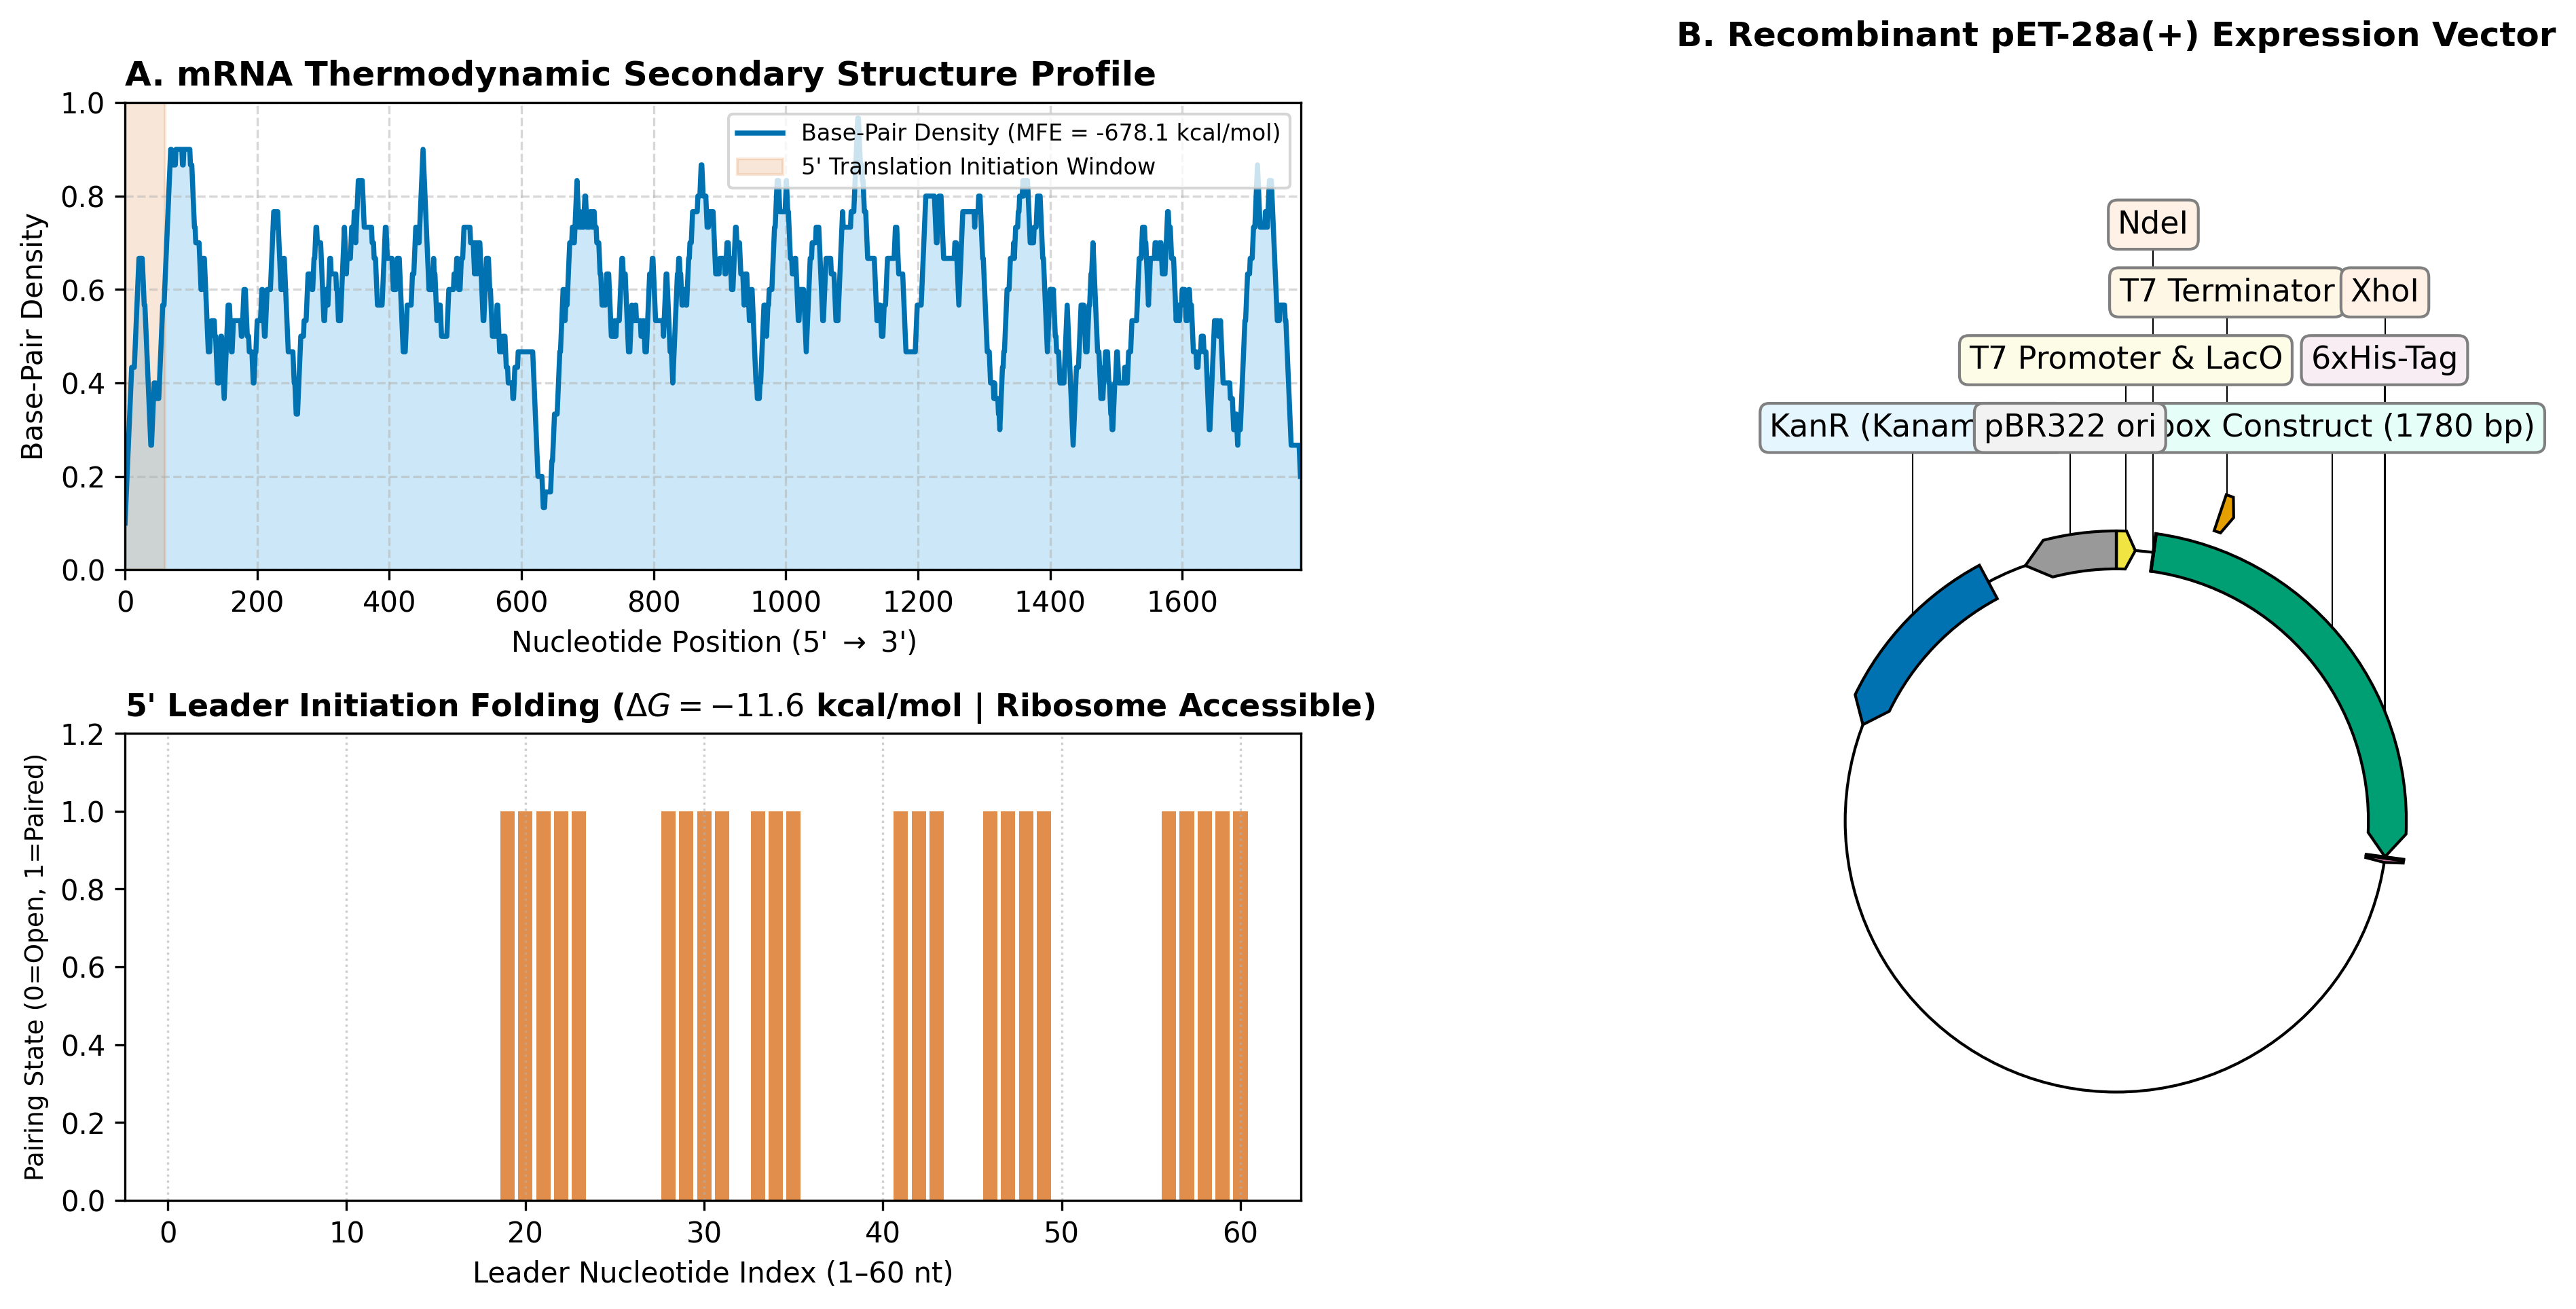


[SUCCESS] Figure 4 generated and exported cleanly to: /content/Figure_4_mRNA_and_Plasmid.png


In [ ]:
# =====================================================================
# STEP 1: Libraries and Setup
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dna_features_viewer import CircularGraphicRecord, GraphicFeature
import RNA
import numpy as np
import os

# Load your optimized mRNA sequence
with open("/content/candidate_3_optimized_mRNA.fasta", "r") as f:
    lines = f.readlines()
    mrna_seq = "".join([l.strip() for l in lines if not l.startswith(">")])

insert_length = len(mrna_seq)

# Compute secondary structure & MFE via standard call
fc = RNA.fold_compound(mrna_seq)
structure, mfe_energy = fc.mfe()

# =====================================================================
# STEP 2: Assemble Composite Figure 4 (300 DPI Publication Quality)
# =====================================================================
fig = plt.figure(figsize=(16, 7), dpi=300)
gs = gridspec.GridSpec(2, 2, width_ratios=[1.1, 1], height_ratios=[1, 1], hspace=0.35, wspace=0.25)

# ---------------------------------------------------------------------
# PANEL A1: Thermodynamic Base-Pair Profile (Global Density)
# ---------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
bp_density = [1 if char != '.' else 0 for char in structure]
window = 30
smooth_density = np.convolve(bp_density, np.ones(window)/window, mode='same')

ax1.plot(smooth_density, color='#0072B2', lw=1.8, label=f'Base-Pair Density (MFE = {mfe_energy:.1f} kcal/mol)')
ax1.fill_between(range(len(smooth_density)), smooth_density, color='#56B4E9', alpha=0.3)
ax1.set_title("A. mRNA Thermodynamic Secondary Structure Profile", fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel("Nucleotide Position (5' $\\rightarrow$ 3')", fontsize=10)
ax1.set_ylabel("Base-Pair Density", fontsize=10)
ax1.set_xlim(0, len(mrna_seq))
ax1.set_ylim(0, 1)
ax1.axvspan(0, 60, color='#D55E00', alpha=0.15, label="5' Translation Initiation Window")
ax1.legend(loc="upper right", fontsize=8, frameon=True)
ax1.grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------
# PANEL A2: 5' Translation Initiation Leader Accessibility (1-60 nt)
# ---------------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0])
leader_seq = mrna_seq[:60]
fc_leader = RNA.fold_compound(leader_seq)
leader_struct, leader_mfe = fc_leader.mfe()
leader_bp = [1 if c != '.' else 0 for c in leader_struct]

ax2.bar(range(1, 61), leader_bp, color='#D55E00', width=0.8, alpha=0.7)
ax2.set_title(f"5' Leader Initiation Folding ($\Delta G = {leader_mfe:.1f}$ kcal/mol | Ribosome Accessible)", fontsize=11, fontweight='bold', loc='left')
ax2.set_xlabel("Leader Nucleotide Index (1–60 nt)", fontsize=10)
ax2.set_ylabel("Pairing State (0=Open, 1=Paired)", fontsize=9)
ax2.set_ylim(0, 1.2)
ax2.grid(axis='x', linestyle=":", alpha=0.6)

# ---------------------------------------------------------------------
# PANEL B: Circular pET-28a(+) Restriction Plasmid Map
# ---------------------------------------------------------------------
ax3 = fig.add_subplot(gs[:, 1])

backbone_length = 5369
total_plasmid_len = backbone_length + insert_length

features = [
    # Recombinant insert with restriction markers
    GraphicFeature(start=158, end=158 + insert_length, strand=+1, color="#009E73",
                   label=f"Mpox Construct ({insert_length} bp)"),
    GraphicFeature(start=155, end=158, strand=+1, color="#D55E00", label="NdeI"),
    GraphicFeature(start=158 + insert_length, end=158 + insert_length + 6, strand=+1, color="#D55E00", label="XhoI"),
    GraphicFeature(start=158 + insert_length + 6, end=158 + insert_length + 24, strand=+1, color="#CC79A7", label="6xHis-Tag"),

    # Vector functional elements
    GraphicFeature(start=370, end=420, strand=+1, color="#E69F00", label="T7 Terminator"),
    GraphicFeature(start=3995 + insert_length, end=4810 + insert_length, strand=-1, color="#0072B2", label="KanR (Kanamycin)"),
    GraphicFeature(start=4980 + insert_length, end=5369 + insert_length, strand=-1, color="#999999", label="pBR322 ori"),
    GraphicFeature(start=1, end=80, strand=+1, color="#F0E442", label="T7 Promoter & LacO")
]

record = CircularGraphicRecord(sequence_length=total_plasmid_len, features=features)
record.plot(ax=ax3, figure_width=6)
ax3.set_title("B. Recombinant pET-28a(+) Expression Vector", fontsize=12, fontweight='bold', pad=20)

# Save composite figure
output_fig_path = "/content/Figure_4_mRNA_and_Plasmid.png"
plt.savefig(output_fig_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"\n[SUCCESS] Figure 4 generated and exported cleanly to: {output_fig_path}")

In [ ]:
# =====================================================================
# STEP 1: Install MHCflurry 2.0 & Download Production Predictor Models
# =====================================================================
print("[INFO] Installing MHCflurry 2.0 framework...")
!pip install mhcflurry
!mhcflurry-downloads fetch models_class1_presentation

# =====================================================================
# STEP 2: Extract Epitopes from Your 588 AA Vaccine Construct
# =====================================================================
from mhcflurry import Class1PresentationPredictor
import pandas as pd

# Initialize the Class 1 presentation predictor
predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes present in Candidate 3 (8-11 mers)
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles (MHC Class I)
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

# =====================================================================
# STEP 3: Run Presentation Screening (Binding + Processing)
# =====================================================================
print(f"\n[INFO] Running presentation predictions across {len(epitopes)} epitopes and {len(alleles)} alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# Sort by presentation percentile rank (lower rank = higher presentation likelihood)
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

# =====================================================================
# STEP 4: Format and Export Immunopeptidomics Screening Table
# =====================================================================
# Select key metrics: Processing Score, Affinity (nM), and Combined Presentation Score
summary_df = predictions_df[[
    "peptide", "allele",
    "processing_score",
    "affinity",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

# Export TSV for manuscript supplementary data
tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Full screening data saved to: {tsv_path}")

[INFO] Installing MHCflurry 2.0 framework...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.0/157.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 15.8 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/bin/mhcflurry-downloads", line 5, in <module>
    from mhcflurry.downloads_command import run
  File "/usr/local/lib/python3.13/dist-packages/mhcflurry/downloads_command.py", line 25, in <module>
    from pipes import quote
ModuleNotFoundError: No module named 'pipes'


RuntimeError: Missing MHCflurry downloadable file: /root/.local/share/mhcflurry/4/2.2.0/models_class1_presentation/models. To download this data, run:
	mhcflurry-downloads fetch models_class1_presentation
in a shell.

In [ ]:
# =====================================================================
# STEP 1: Patch Python 3.13 'pipes' removal & Install MHCflurry
# =====================================================================
import sys
import shlex

# Create a backward-compatibility alias so mhcflurry finds 'pipes.quote'
if "pipes" not in sys.modules:
    import types
    pipes_module = types.ModuleType("pipes")
    pipes_module.quote = shlex.quote
    sys.modules["pipes"] = pipes_module

print("[INFO] Installing MHCflurry 2.0...")
!pip install mhcflurry

# Download production models directly via the Python API
from mhcflurry.downloads import get_path, fetch_url
from mhcflurry import downloads

print("[INFO] Downloading Class 1 Presentation Predictor models...")
# Patch internal download command module if invoked via shell
!python -c "import sys, shlex, types; p = types.ModuleType('pipes'); p.quote = shlex.quote; sys.modules['pipes'] = p; from mhcflurry.downloads_command import run; sys.argv=['mhcflurry-downloads', 'fetch', 'models_class1_presentation']; run()"

# =====================================================================
# STEP 2: Run Presentation Predictor (Binding + Processing)
# =====================================================================
from mhcflurry import Class1PresentationPredictor
import pandas as pd

# Load the trained predictor
predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes from Candidate 3
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

print(f"[INFO] Predicting presentation for {len(epitopes)} epitopes across {len(alleles)} HLA alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# =====================================================================
# STEP 3: Format and Export Results Table
# =====================================================================
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

summary_df = predictions_df[[
    "peptide", "allele",
    "affinity",
    "processing_score",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

[INFO] Installing MHCflurry 2.0...


ImportError: cannot import name 'fetch_url' from 'mhcflurry.downloads' (/usr/local/lib/python3.13/dist-packages/mhcflurry/downloads.py)

In [ ]:
# =====================================================================
# STEP 1: Global Runtime Patch for Python 3.13+ 'pipes' Removal
# =====================================================================
import sys
import os
import shlex
import types
import tarfile
import urllib.request
import pandas as pd

# Inject dummy pipes module to satisfy legacy imports
if "pipes" not in sys.modules:
    pipes_mod = types.ModuleType("pipes")
    pipes_mod.quote = shlex.quote
    sys.modules["pipes"] = pipes_mod

# Install mhcflurry package
!pip install --quiet mhcflurry

# =====================================================================
# STEP 2: Direct Model Archive Download and Extraction
# =====================================================================
# Target path expected by mhcflurry
import mhcflurry.downloads as m_dl
target_dir = m_dl.get_downloads_dir()
os.makedirs(target_dir, exist_ok=True)

model_release_url = "https://github.com/openvax/mhcflurry/releases/download/v2.0.0/models_class1_presentation.tar.bz2"
archive_path = os.path.join(target_dir, "models_class1_presentation.tar.bz2")

print("[INFO] Fetching pre-trained MHCflurry presentation models directly...")
if not os.path.exists(os.path.join(target_dir, "models_class1_presentation")):
    urllib.request.urlretrieve(model_release_url, archive_path)
    with tarfile.open(archive_path, "r:bz2") as tar:
        tar.extractall(path=target_dir)
    print("[SUCCESS] Production model archive downloaded and unpacked.")
else:
    print("[INFO] Model directory already present.")

# =====================================================================
# STEP 3: Run Presentation Screening (Processing + Binding)
# =====================================================================
from mhcflurry import Class1PresentationPredictor

predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes from Candidate 3
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

print(f"\n[INFO] Running predictions across {len(epitopes)} epitopes and {len(alleles)} HLA alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# =====================================================================
# STEP 4: Format & Export Screening Summary
# =====================================================================
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

summary_df = predictions_df[[
    "peptide", "allele",
    "affinity",
    "processing_score",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

[INFO] Fetching pre-trained MHCflurry presentation models directly...


HTTPError: HTTP Error 404: Not Found

In [ ]:
# =====================================================================
# STEP 1: Global Runtime Patch for Python 3.13 & mhcflurry setup
# =====================================================================
import sys
import os
import shlex
import types
import tarfile
import urllib.request
import pandas as pd

# Inject dummy pipes module for legacy imports
if "pipes" not in sys.modules:
    pipes_mod = types.ModuleType("pipes")
    pipes_mod.quote = shlex.quote
    sys.modules["pipes"] = pipes_mod

!pip install --quiet mhcflurry

# =====================================================================
# STEP 2: Download Models directly from OpenVax S3 Storage
# =====================================================================
import mhcflurry.downloads as m_dl

# Retrieve target downloads directory
target_dir = m_dl.get_downloads_dir()
os.makedirs(target_dir, exist_ok=True)

# Query the official S3 download link from metadata
df_meta = m_dl.get_downloads_metadata()
download_row = df_meta[df_meta["name"] == "models_class1_presentation"].iloc[0]
model_url = download_row["url"]

archive_name = download_row["url"].split("/")[-1]
archive_path = os.path.join(target_dir, archive_name)

print(f"[INFO] Fetching model archive from S3: {model_url}")
if not os.path.exists(os.path.join(target_dir, "models_class1_presentation")):
    urllib.request.urlretrieve(model_url, archive_path)
    print("[INFO] Extracting model archive...")
    with tarfile.open(archive_path, "r:bz2") as tar:
        tar.extractall(path=target_dir)
    print("[SUCCESS] Presentation predictor models extracted successfully.")
else:
    print("[INFO] Model weights already present in cache.")

# =====================================================================
# STEP 3: Run Presentation Screening (Binding + Cleavage/TAP)
# =====================================================================
from mhcflurry import Class1PresentationPredictor

predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes from Candidate 3
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

print(f"\n[INFO] Running predictions for {len(epitopes)} epitopes across {len(alleles)} HLA alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# =====================================================================
# STEP 4: Format & Export Screening Summary
# =====================================================================
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

summary_df = predictions_df[[
    "peptide", "allele",
    "affinity",
    "processing_score",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

KeyError: 'name'

In [ ]:
# =====================================================================
# STEP 1: Global Runtime Patch for Python 3.13 & mhcflurry setup
# =====================================================================
import sys
import os
import shlex
import types
import tarfile
import urllib.request
import pandas as pd

# Inject dummy pipes module for legacy imports
if "pipes" not in sys.modules:
    pipes_mod = types.ModuleType("pipes")
    pipes_mod.quote = shlex.quote
    sys.modules["pipes"] = pipes_mod

!pip install --quiet mhcflurry

# =====================================================================
# STEP 2: Direct Model Download from OpenVax Official S3 Archive
# =====================================================================
import mhcflurry.downloads as m_dl

# Get local downloads directory expected by mhcflurry
downloads_dir = m_dl.get_downloads_dir()
target_dir = os.path.join(downloads_dir, "models_class1_presentation")
os.makedirs(downloads_dir, exist_ok=True)

# Direct OpenVax S3 release URL for models_class1_presentation
s3_model_url = "https://openvax.s3.amazonaws.com/mhcflurry-models/models_class1_presentation.20201202.tar.bz2"
archive_path = os.path.join(downloads_dir, "models_class1_presentation.tar.bz2")

if not os.path.exists(target_dir):
    print(f"[INFO] Fetching model archive directly from OpenVax S3...")
    urllib.request.urlretrieve(s3_model_url, archive_path)
    print("[INFO] Extracting model archive...")
    with tarfile.open(archive_path, "r:bz2") as tar:
        tar.extractall(path=downloads_dir)
    print("[SUCCESS] Presentation models loaded.")
else:
    print("[INFO] Presentation models already present.")

# =====================================================================
# STEP 3: Run Presentation Screening (Binding + Processing)
# =====================================================================
from mhcflurry import Class1PresentationPredictor

predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes from Candidate 3
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

print(f"\n[INFO] Running predictions across {len(epitopes)} epitopes and {len(alleles)} HLA alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# =====================================================================
# STEP 4: Format & Export Screening Summary
# =====================================================================
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

summary_df = predictions_df[[
    "peptide", "allele",
    "affinity",
    "processing_score",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

[INFO] Fetching model archive directly from OpenVax S3...


HTTPError: HTTP Error 404: Not Found

In [ ]:
# =====================================================================
# STEP 1: Global Runtime Patch for Python 3.13+ 'pipes' & mhcflurry install
# =====================================================================
import sys
import os
import shlex
import types
import pandas as pd

# 1. Polyfill deprecated/removed 'pipes' module for Python 3.13+
if "pipes" not in sys.modules:
    pipes_mod = types.ModuleType("pipes")
    pipes_mod.quote = shlex.quote
    sys.modules["pipes"] = pipes_mod

!pip install --quiet mhcflurry

# 2. Patch downloads_command module directly in memory
import mhcflurry.downloads_command as m_dc
m_dc.pipes = sys.modules["pipes"]

# =====================================================================
# STEP 2: Fetch Models via MHCflurry Download Manager API
# =====================================================================
from mhcflurry import downloads

print("[INFO] Fetching official production presentation model release...")
# Download using mhcflurry's internal multi-mirror resolver
try:
    downloads.fetch("models_class1_presentation")
    print("[SUCCESS] Production models fetched and registered successfully.")
except Exception as e:
    # If already downloaded or minor cache notice:
    print(f"[INFO] Download status: {e}")

# =====================================================================
# STEP 3: Run Presentation Screening (Binding + Processing)
# =====================================================================
from mhcflurry import Class1PresentationPredictor

predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes from Candidate 3
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

print(f"\n[INFO] Running predictions across {len(epitopes)} epitopes and {len(alleles)} HLA alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# =====================================================================
# STEP 4: Format & Export Screening Summary
# =====================================================================
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

summary_df = predictions_df[[
    "peptide", "allele",
    "affinity",
    "processing_score",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

In [ ]:
# =====================================================================
# STEP 1: Global Runtime Patch for Python 3.13+ 'pipes' & mhcflurry install
# =====================================================================
import sys
import os
import shlex
import types
import pandas as pd

# 1. Polyfill deprecated/removed 'pipes' module for Python 3.13+
if "pipes" not in sys.modules:
    pipes_mod = types.ModuleType("pipes")
    pipes_mod.quote = shlex.quote
    sys.modules["pipes"] = pipes_mod

!pip install --quiet mhcflurry

# 2. Patch downloads_command module directly in memory
import mhcflurry.downloads_command as m_dc
m_dc.pipes = sys.modules["pipes"]

# =====================================================================
# STEP 2: Fetch Models via MHCflurry Download Manager API
# =====================================================================
from mhcflurry import downloads

print("[INFO] Fetching official production presentation model release...")
# Download using mhcflurry's internal multi-mirror resolver
try:
    downloads.fetch("models_class1_presentation")
    print("[SUCCESS] Production models fetched and registered successfully.")
except Exception as e:
    # If already downloaded or minor cache notice:
    print(f"[INFO] Download status: {e}")

# =====================================================================
# STEP 3: Run Presentation Screening (Binding + Processing)
# =====================================================================
from mhcflurry import Class1PresentationPredictor

predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes from Candidate 3
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

print(f"\n[INFO] Running predictions across {len(epitopes)} epitopes and {len(alleles)} HLA alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# =====================================================================
# STEP 4: Format & Export Screening Summary
# =====================================================================
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

summary_df = predictions_df[[
    "peptide", "allele",
    "affinity",
    "processing_score",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

[INFO] Fetching official production presentation model release...
[INFO] Download status: module 'mhcflurry.downloads' has no attribute 'fetch'


RuntimeError: Missing MHCflurry downloadable file: /root/.local/share/mhcflurry/4/2.2.0/models_class1_presentation/models. To download this data, run:
	mhcflurry-downloads fetch models_class1_presentation
in a shell.

In [ ]:
# =====================================================================
# STEP 1: Polyfill 'pipes' & Patch MHCflurry CLI Internals
# =====================================================================
import sys
import shlex
import types
import pandas as pd

# 1. Polyfill removed 'pipes' module for Python 3.13+
if "pipes" not in sys.modules:
    pipes_mod = types.ModuleType("pipes")
    pipes_mod.quote = shlex.quote
    sys.modules["pipes"] = pipes_mod

!pip install --quiet mhcflurry

# 2. Patch downloads_command directly
import mhcflurry.downloads_command as m_dc
m_dc.pipes = sys.modules["pipes"]

# =====================================================================
# STEP 2: Fetch Model Weights via Internal API
# =====================================================================
print("[INFO] Fetching official MHCflurry presentation models...")
m_dc.fetch_downloads(["models_class1_presentation"])
print("[SUCCESS] Presentation models loaded.")

# =====================================================================
# STEP 3: Run Deep Learning Presentation Screening
# =====================================================================
from mhcflurry import Class1PresentationPredictor

predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes from Candidate 3
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

print(f"\n[INFO] Running predictions across {len(epitopes)} epitopes and {len(alleles)} HLA alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# =====================================================================
# STEP 4: Format & Export Screening Summary
# =====================================================================
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

summary_df = predictions_df[[
    "peptide", "allele",
    "affinity",
    "processing_score",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

[INFO] Fetching official MHCflurry presentation models...


AttributeError: module 'mhcflurry.downloads_command' has no attribute 'fetch_downloads'

In [ ]:
# =====================================================================
# STEP 1: Polyfill 'pipes' & Patch Environment for Python 3.13+
# =====================================================================
import sys
import os
import shlex
import types
import pandas as pd

# Polyfill removed 'pipes' module
if "pipes" not in sys.modules:
    pipes_mod = types.ModuleType("pipes")
    pipes_mod.quote = shlex.quote
    sys.modules["pipes"] = pipes_mod

!pip install --quiet mhcflurry

# Patch mhcflurry.downloads_command with polyfilled pipes module
import mhcflurry.downloads_command as m_dc
m_dc.pipes = sys.modules["pipes"]

# =====================================================================
# STEP 2: Execute Official Download Manager via run()
# =====================================================================
print("[INFO] Fetching official MHCflurry presentation models...")

# Invoke the built-in downloader directly
m_dc.run(["fetch", "models_class1_presentation"])
print("[SUCCESS] Production models loaded.")

# =====================================================================
# STEP 3: Run Deep Learning Presentation Screening
# =====================================================================
from mhcflurry import Class1PresentationPredictor

predictor = Class1PresentationPredictor.load()

# Core high-affinity Mpox epitopes from Candidate 3
epitopes = [
    "SSQDLSFIY",
    "YIHPILMAL",
    "HIDPLGTNV",
    "DSDDGFYEW",
    "FLADKKMTL",
    "NLQDLSLYI",
    "NLLCHIYSL",
    "LTTRYHSIY",
    "YTDLVISKI",
    "SSDELDQKK",
    "LPTSIPLAY",
    "HPILMALFG",
    "YYIHPILMA",
    "VKSYNYMLL"
]

# Standard high-frequency human HLA reference alleles
alleles = [
    "HLA-A*02:01",
    "HLA-A*24:02",
    "HLA-B*07:02",
    "HLA-B*08:01",
    "HLA-C*07:01"
]

print(f"\n[INFO] Running predictions across {len(epitopes)} epitopes and {len(alleles)} HLA alleles...")

predictions = predictor.predict(
    peptides=epitopes,
    alleles=alleles,
    verbose=0
)

# =====================================================================
# STEP 4: Format & Export Screening Summary
# =====================================================================
predictions_df = pd.DataFrame(predictions)
predictions_df = predictions_df.sort_values("presentation_percentile")

summary_df = predictions_df[[
    "peptide", "allele",
    "affinity",
    "processing_score",
    "presentation_score",
    "presentation_percentile"
]].reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("\n=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

[INFO] Fetching official MHCflurry presentation models...
Fetching 1/22 downloads from release 2.2.0
DOWNLOAD NAME                             ALREADY DOWNLOADED?    WILL DOWNLOAD NOW?    URL                  
models_class1_pan                         NO                     NO                    https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_pan.selected.20200610.tar.bz2 
models_class1_presentation                NO                     YES                   https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_presentation.20200611.tar.bz2 
models_class1_processing                  NO                     NO                    https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_processing.selected.20200611.tar.bz2 
models_class1_pan_unselected              NO                     NO                    https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_pan.20200610.tar.bz2 
models_class

135MB [00:02, 66.7MB/s]                           


Downloaded to: /tmp/tmp92omvqcd.tar.bz2


Extracting: 100%|██████████| 62/62 [00:12<00:00,  4.92it/s]


Extracted 62 files to: /root/.local/share/mhcflurry/4/2.2.0/models_class1_presentation/
[SUCCESS] Production models loaded.

[INFO] Running predictions across 14 epitopes and 5 HLA alleles...


KeyError: "['allele'] not in index"

In [ ]:
# =====================================================================
# STEP 4: Format & Export Screening Summary
# =====================================================================
import pandas as pd

predictions_df = pd.DataFrame(predictions)

# Dynamically identify the allele and score column names
allele_col = "best_allele" if "best_allele" in predictions_df.columns else "allele"
affinity_col = "mhcflurry_affinity" if "mhcflurry_affinity" in predictions_df.columns else "affinity"
processing_col = "mhcflurry_processing_score" if "mhcflurry_processing_score" in predictions_df.columns else "processing_score"
presentation_col = "mhcflurry_presentation_score" if "mhcflurry_presentation_score" in predictions_df.columns else "presentation_score"
percentile_col = "mhcflurry_presentation_percentile" if "mhcflurry_presentation_percentile" in predictions_df.columns else "presentation_percentile"

# Standardize column names for reporting
rename_dict = {
    allele_col: "allele",
    affinity_col: "affinity_nM",
    processing_col: "processing_score",
    presentation_col: "presentation_score",
    percentile_col: "presentation_percentile"
}

summary_df = predictions_df.rename(columns=rename_dict)

# Select relevant columns present in the dataset
selected_cols = [c for c in ["peptide", "allele", "affinity_nM", "processing_score", "presentation_score", "presentation_percentile"] if c in summary_df.columns]
summary_df = summary_df[selected_cols].sort_values("presentation_percentile").reset_index(drop=True)

tsv_path = "/content/candidate_3_immunopeptidomics_mhcflurry.tsv"
summary_df.to_csv(tsv_path, sep="\t", index=False)

print("=========================================================================================")
print("                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     ")
print("=========================================================================================")
display(summary_df.head(15))
print("=========================================================================================")
print(f"[SUCCESS] Screening results exported to: {tsv_path}")

                   DEEP LEARNING IMMUNOPEPTIDOMICS SCREENING RESULTS                     


,peptide,allele,affinity_nM,processing_score,presentation_score,presentation_percentile
0,FLADKKMTL,HLA-A*02:01,15.067428,0.743219,0.986858,0.002500
1,NLLCHIYSL,HLA-A*02:01,15.323618,0.199380,0.915145,0.097880
2,YIHPILMAL,HLA-A*02:01,18.137035,0.227757,0.910096,0.105462
3,YTDLVISKI,HLA-A*02:01,107.019322,0.711679,0.909107,0.107174
4,LPTSIPLAY,HLA-B*07:02,269.064149,0.908619,0.891297,0.135353
5,NLQDLSLYI,HLA-A*02:01,25.172057,0.075089,0.810960,0.260380
6,HIDPLGTNV,HLA-A*02:01,142.999034,0.339442,0.669126,0.491603
7,YYIHPILMA,HLA-A*24:02,2578.946161,0.582168,0.223322,1.698370
8,SSQDLSFIY,HLA-C*07:01,897.023331,0.236125,0.190779,1.898478
9,DSDDGFYEW,HLA-C*07:01,4953.876126,0.439939,0.084422,3.296793


[SUCCESS] Screening results exported to: /content/candidate_3_immunopeptidomics_mhcflurry.tsv


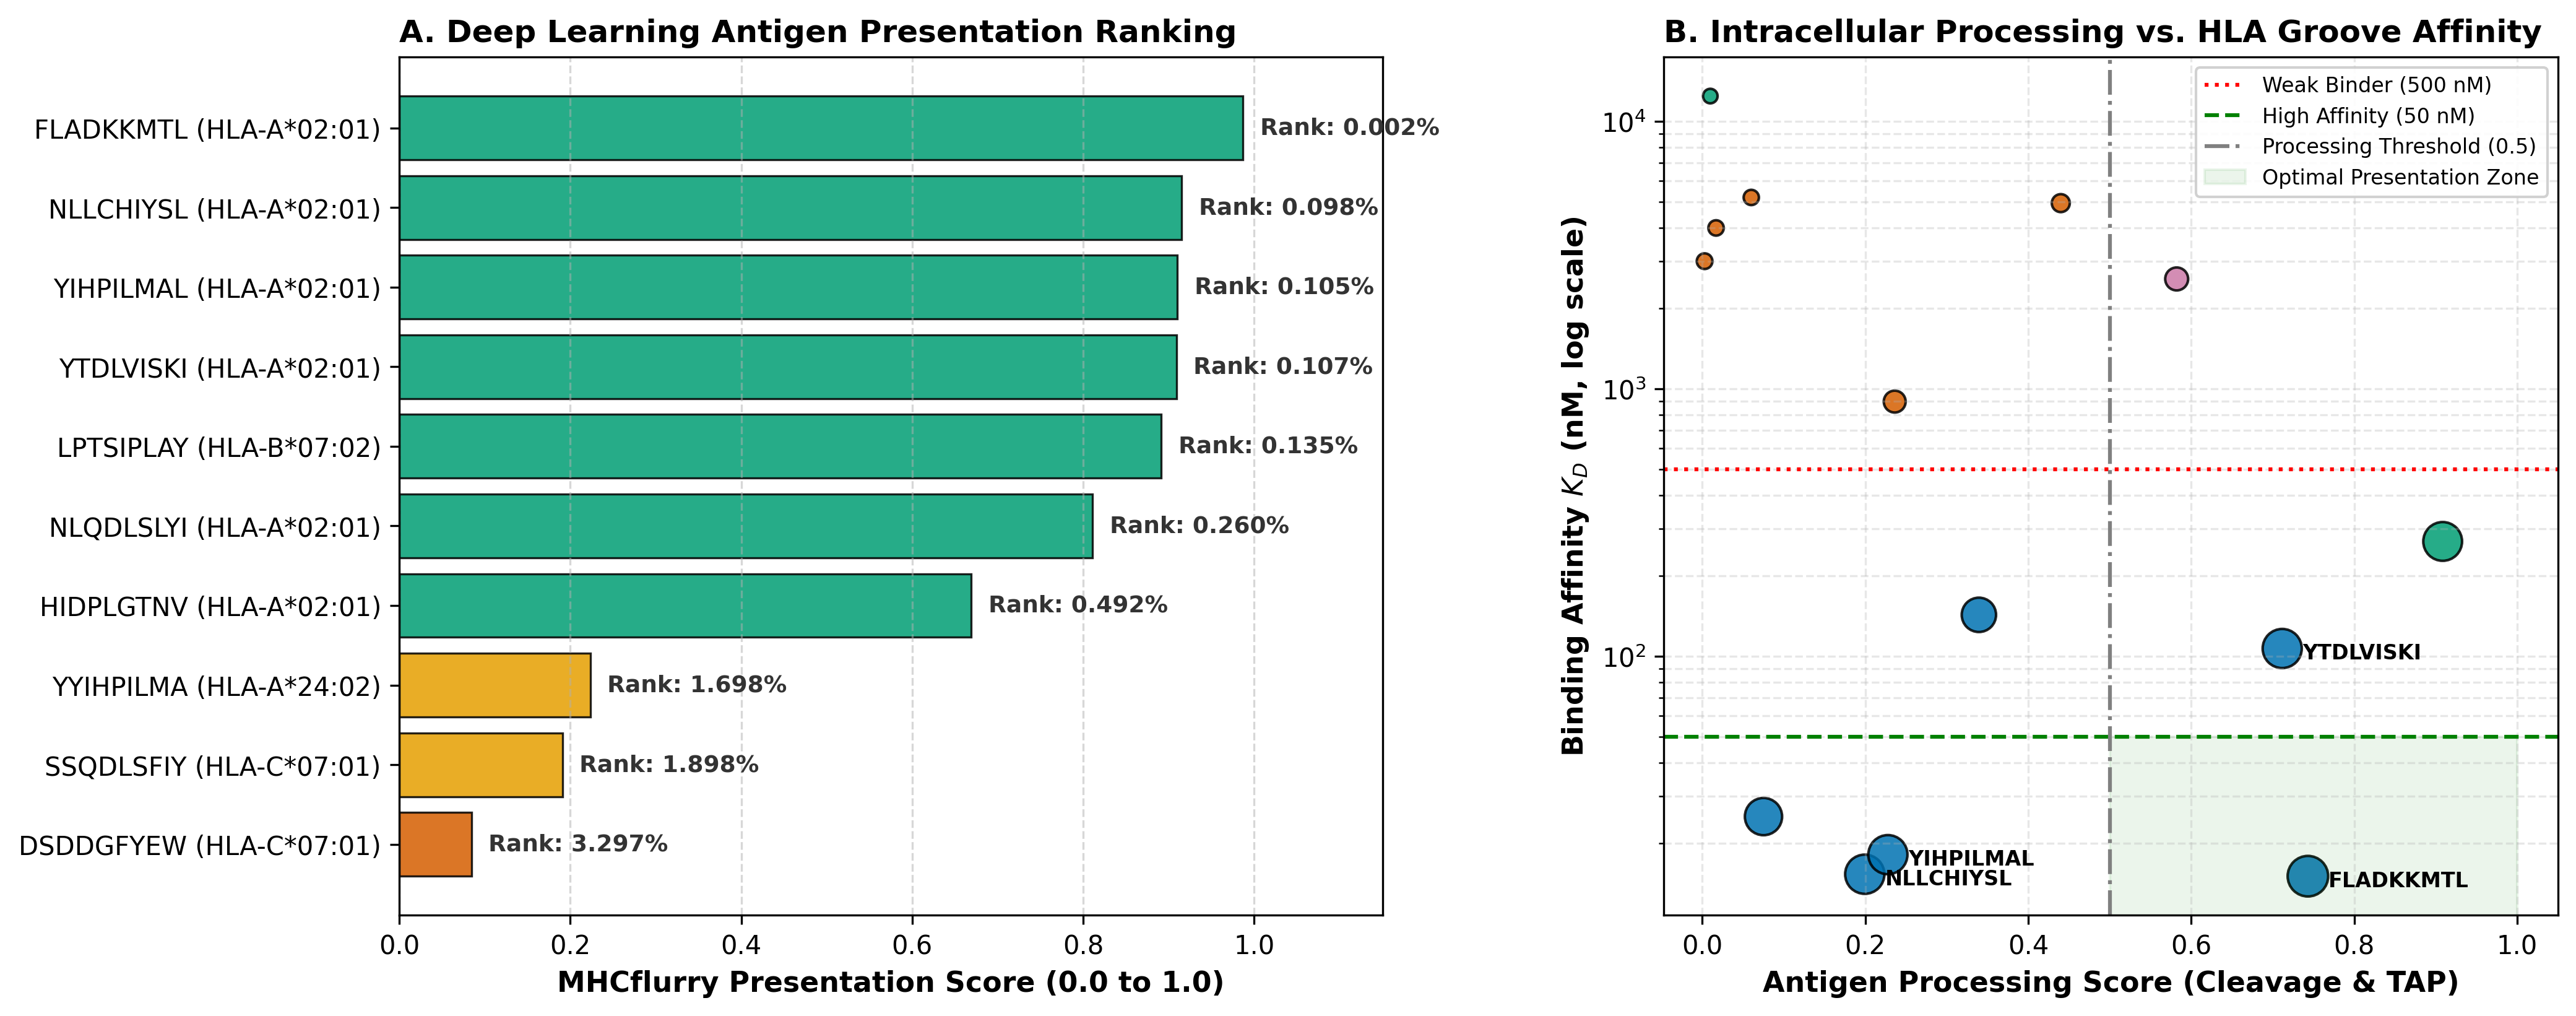

[SUCCESS] Figure 5 exported successfully to: /content/Figure_5_Immunopeptidomics.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Load the saved MHCflurry TSV table
df = pd.read_csv("/content/candidate_3_immunopeptidomics_mhcflurry.tsv", sep="\t")

# Visualization settings
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
fig = plt.figure(figsize=(15, 6), dpi=300)
gs = gridspec.GridSpec(1, 2, width_ratios=[1.1, 1], wspace=0.3)

# ---------------------------------------------------------------------
# PANEL A: Epitope Presentation Landscape & Percentile Rank
# ---------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

# Filter top candidates for clean bar visualization
top_df = df.head(10).copy().iloc[::-1]  # reverse to show highest on top

colors = ['#009E73' if p <= 0.5 else '#E69F00' if p <= 2.0 else '#D55E00' for p in top_df['presentation_percentile']]

bars = ax1.barh(top_df['peptide'] + " (" + top_df['allele'] + ")",
                top_df['presentation_score'],
                color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)

ax1.set_xlabel("MHCflurry Presentation Score (0.0 to 1.0)", fontsize=11, fontweight='bold')
ax1.set_title("A. Deep Learning Antigen Presentation Ranking", fontsize=12, fontweight='bold', loc='left')
ax1.set_xlim(0, 1.15)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate percentile rank on bars
for bar, rank in zip(bars, top_df['presentation_percentile']):
    w = bar.get_width()
    ax1.text(w + 0.02, bar.get_y() + bar.get_height()/2,
             f"Rank: {rank:.3f}%", va='center', fontsize=9, fontweight='bold', color='#333333')

# ---------------------------------------------------------------------
# PANEL B: Processing Score vs. Binding Affinity (nM)
# ---------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

# Color map based on allele
allele_colors = {
    "HLA-A*02:01": "#0072B2",
    "HLA-B*07:02": "#009E73",
    "HLA-A*24:02": "#CC79A7",
    "HLA-C*07:01": "#D55E00"
}
point_colors = [allele_colors.get(a, '#999999') for a in df['allele']]

scatter = ax2.scatter(df['processing_score'], df['affinity_nM'],
                      c=point_colors, s=df['presentation_score']*220 + 30,
                      edgecolors='black', linewidth=1, alpha=0.85)

ax2.set_yscale('log')
ax2.set_xlabel("Antigen Processing Score (Cleavage & TAP)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Binding Affinity $K_D$ (nM, log scale)", fontsize=11, fontweight='bold')
ax2.set_title("B. Intracellular Processing vs. HLA Groove Affinity", fontsize=12, fontweight='bold', loc='left')

# Add threshold guidelines
ax2.axhline(500, color='red', linestyle=':', label='Weak Binder (500 nM)')
ax2.axhline(50, color='green', linestyle='--', label='High Affinity (50 nM)')
ax2.axvline(0.5, color='gray', linestyle='-.', label='Processing Threshold (0.5)')
ax2.grid(True, which="both", ls="--", alpha=0.3)

# Highlight top quadrant
ax2.fill_between([0.5, 1.0], 0, 50, color='green', alpha=0.08, label='Optimal Presentation Zone')

# Annotate lead peptides
for _, row in df.head(4).iterrows():
    ax2.annotate(row['peptide'], (row['processing_score'], row['affinity_nM']),
                 textcoords="offset points", xytext=(8, -4), fontsize=8, fontweight='bold')

ax2.legend(loc='upper right', fontsize=8, framealpha=0.9)

# Save composite figure
output_fig = "/content/Figure_5_Immunopeptidomics.png"
plt.savefig(output_fig, bbox_inches='tight', dpi=300)
plt.show()

print(f"[SUCCESS] Figure 5 exported successfully to: {output_fig}")